In [5]:
import io
import matplotlib.pyplot as plt
import pandas as pd

raw_data = """Date,Description,Amount
2026-08-01,Whole Foods Groceries,145.20
2026-08-02,Apartment Rent,1250.00
2026-08-03,Shell Gas Station,45.00
2026-08-05,Netflix Subscription,15.99
2026-08-07,Trader Joe's,82.40
2026-08-10,Electric Utility Bill,95.50
2026-08-12,Uber Ride,28.50
2026-08-15,Starbucks Coffee,12.75
2026-08-18,Dinner at Italian Bistro,78.00
2026-08-22,Spotify,10.99
2026-08-25,Water Utility,42.00
2026-08-28,Amazon Electronics,115.00
"""

#create a Dataframe and new csv file with the data
with open("expences.csv", 'w') as f:
    f.write(raw_data)   

# Load into DataFrame and parse dates
df = pd.read_csv("expences.csv")
df["Date"] = pd.to_datetime(df["Date"])
# print(df.head())

In [4]:
category_rules = {
    "Housing": ["rent", "mortgage"],
    "Groceries": ["whole foods", "trader joe", "market", "grocery"],
    "Utilities": ["electric", "water", "internet", "utility"],
    "Dining": ["bistro", "starbucks", "restaurant", "cafe"],
    "Transportation": ["gas", "uber", "lyft", "shell"],
    "Entertainment": ["netflix", "spotify", "hulu", "cinema"],
    "Shopping": ["amazon", "clothing", "target"],
}


def auto_categorize(desc):
    desc_clean = desc.lower()
    for category, keywords in category_rules.items():
        if any(keyword in desc_clean for keyword in keywords):
            return category
    return "Miscellaneous"


df["Category"] = df["Description"].apply(auto_categorize)
# print(df[["Date", "Description", "Amount", "Category"]])

In [ ]:
monthly_income = 3500.00
total_expenses = df["Amount"].sum()
monthly_savings = monthly_income - total_expenses
savings_rate = (monthly_savings / monthly_income) * 100

print(f"Monthly Income : ${monthly_income:,.2f}")
print(f"Total Expenses : ${total_expenses:,.2f}")
print(f"Net Savings    : ${monthly_savings:,.2f}")
print(f"Savings Rate   : {savings_rate:.2f}%")

# Category-level budget targets
budget_limits = {
    "Housing": 1300.00,
    "Groceries": 250.00,
    "Utilities": 150.00,
    "Dining": 120.00,
    "Transportation": 100.00,
    "Entertainment": 40.00,
    "Shopping": 100.00,
    "Miscellaneous": 50.00,
}

# Aggregate actual spending by category
budget_summary = (
    df.groupby("Category")["Amount"].sum().reset_index(name="Actual_Spent")
)
budget_summary["Budget_Limit"] = budget_summary["Category"].map(budget_limits)
budget_summary["Variance"] = (
    budget_summary["Budget_Limit"] - budget_summary["Actual_Spent"]
)
budget_summary["Status"] = budget_summary["Variance"].apply(
    lambda x: "Within Budget" if x >= 0 else "Over Budget"
)

Monthly Income : $3,500.00
Total Expenses : $1,921.33
Net Savings    : $1,578.67
Savings Rate   : 45.10%


KeyError: 'Category'

KeyError: 'Category'

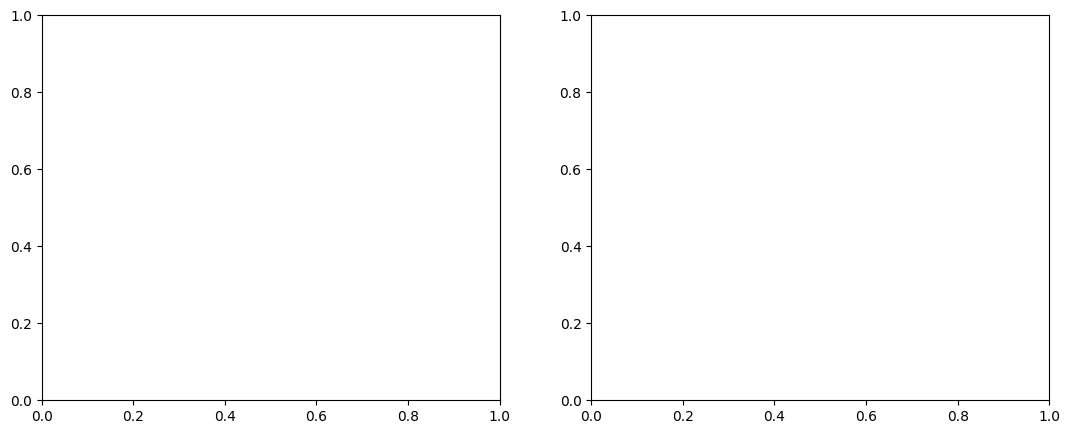

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Spending by Category
category_totals = (
    df.groupby("Category")["Amount"].sum().sort_values(ascending=True)
)
axes[0].barh(
    category_totals.index, category_totals.values, color="#4F46E5", alpha=0.85
)
axes[0].set_title("Spending Breakdown by Category")
axes[0].set_xlabel("Total Spent ($)")
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

# 2. Cumulative Daily Spending Trend
daily_spending = df.groupby("Date")["Amount"].sum().sort_index()
cumulative_spending = daily_spending.cumsum()

axes[1].plot(
    cumulative_spending.index,
    cumulative_spending.values,
    marker="o",
    color="#059669",
    linewidth=2,
)
axes[1].axhline(
    monthly_income,
    color="#DC2626",
    linestyle="--",
    label=f"Income Cap (${monthly_income:,.0f})",
)
axes[1].set_title("Cumulative Monthly Spending Trend")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total Spent ($)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Export categorized transaction log
df.to_csv("categorized_expenses.csv", index=False)

# Export consolidated budget performance report
budget_summary.to_csv("monthly_budget_summary.csv", index=False)

print("Export complete: Saved to 'categorized_expenses.csv' and 'monthly_budget_summary.csv'.")